In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

from pathlib import Path
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

RAW_DIR = Path("/Users/tonytony/Final Project/Data/Raw")

GDP_PATH = RAW_DIR / "gdp.csv"
LIFE_PATH = RAW_DIR / "life_expectancy.csv"
POP_PATH = RAW_DIR / "population.csv"
INFLATION_PATH = RAW_DIR / "inflation.csv"
UNEMPLOYMENT_PATH = RAW_DIR / "unemployment.csv"
META_PATH = RAW_DIR / "world_bank_country_metadata.csv"

internet_candidates = sorted(RAW_DIR.glob("*Internet*.csv"))
if len(internet_candidates) == 0:
    raise FileNotFoundError("Internet dataset not found in Data/Raw")
INTERNET_PATH = internet_candidates[0]

print("GDP:", GDP_PATH)
print("Life:", LIFE_PATH)
print("Population:", POP_PATH)
print("Inflation:", INFLATION_PATH)
print("Unemployment:", UNEMPLOYMENT_PATH)
print("Internet:", INTERNET_PATH)
print("Metadata:", META_PATH)


GDP: /Users/tonytony/Final Project/Data/Raw/gdp.csv
Life: /Users/tonytony/Final Project/Data/Raw/life_expectancy.csv
Population: /Users/tonytony/Final Project/Data/Raw/population.csv
Inflation: /Users/tonytony/Final Project/Data/Raw/inflation.csv
Unemployment: /Users/tonytony/Final Project/Data/Raw/unemployment.csv
Internet: /Users/tonytony/Final Project/Data/Raw/individuals_using_ the_Internet.csv
Metadata: /Users/tonytony/Final Project/Data/Raw/world_bank_country_metadata.csv


In [2]:
meta_df = pd.read_csv(META_PATH)

region_map = meta_df[[
    "Country Code",
    "World Bank Region"
]].copy().rename(columns={
    "Country Code": "country_code",
    "World Bank Region": "wb_region"
})

region_map["country_type"] = np.where(
    region_map["wb_region"].astype(str).str.strip().eq("Aggregates"),
    "Aggregate",
    "Country/Territory"
)

def load_wdi(path):
    df = pd.read_csv(path, skiprows=4)
    df = df.drop(
        columns=[col for col in df.columns if str(col).startswith("Unnamed")],
        errors="ignore"
    )
    year_cols = [col for col in df.columns if str(col).isdigit()]
    df[year_cols] = df[year_cols].apply(pd.to_numeric, errors="coerce")
    return df

def to_long(df, value_name):
    long_df = df.melt(
        id_vars=["Country Name", "Country Code", "Indicator Name", "Indicator Code"],
        value_vars=[col for col in df.columns if str(col).isdigit()],
        var_name="year",
        value_name=value_name
    ).rename(columns={
        "Country Name": "country_name",
        "Country Code": "country_code",
        "Indicator Name": "indicator_name",
        "Indicator Code": "indicator_code"
    })

    long_df["year"] = pd.to_numeric(long_df["year"], errors="coerce").astype("int64")
    long_df[value_name] = pd.to_numeric(long_df[value_name], errors="coerce")
    return long_df

def add_region_info(long_df):
    merged = long_df.merge(region_map, on="country_code", how="left")
    merged = merged[merged["country_type"] == "Country/Territory"].copy()
    return merged

print("Helpers ready")
region_map.head()


Helpers ready


,country_code,wb_region,country_type
0,ABW,Latin America & Caribbean,Country/Territory
1,AFE,Aggregates,Aggregate
2,AFG,"Middle East, North Africa, Afghanistan & Pakistan",Country/Territory
3,AFR,Aggregates,Aggregate
4,AFW,Aggregates,Aggregate


In [3]:
gdp_long = add_region_info(to_long(load_wdi(GDP_PATH), "gdp_per_capita_usd"))
life_long = add_region_info(to_long(load_wdi(LIFE_PATH), "life_expectancy_years"))
pop_long = add_region_info(to_long(load_wdi(POP_PATH), "population_total"))
inflation_long = add_region_info(to_long(load_wdi(INFLATION_PATH), "inflation_pct"))
unemployment_long = add_region_info(to_long(load_wdi(UNEMPLOYMENT_PATH), "unemployment_pct"))
internet_long = add_region_info(to_long(load_wdi(INTERNET_PATH), "internet_users_pct"))

gdp_long = gdp_long[(gdp_long["gdp_per_capita_usd"].notna()) & (gdp_long["gdp_per_capita_usd"] > 0)].copy()
life_long = life_long[life_long["life_expectancy_years"].notna()].copy()
pop_long = pop_long[(pop_long["population_total"].notna()) & (pop_long["population_total"] > 0)].copy()
inflation_long = inflation_long[inflation_long["inflation_pct"].notna()].copy()
unemployment_long = unemployment_long[unemployment_long["unemployment_pct"].notna()].copy()
internet_long = internet_long[internet_long["internet_users_pct"].notna()].copy()

print("GDP latest year:", int(gdp_long["year"].max()))
print("Life latest year:", int(life_long["year"].max()))
print("Population latest year:", int(pop_long["year"].max()))
print("Inflation latest year:", int(inflation_long["year"].max()))
print("Unemployment latest year:", int(unemployment_long["year"].max()))
print("Internet latest year:", int(internet_long["year"].max()))


GDP latest year: 2024
Life latest year: 2023
Population latest year: 2024
Inflation latest year: 2024
Unemployment latest year: 2025
Internet latest year: 2025


In [4]:
panel_df = gdp_long[[
    "country_name",
    "country_code",
    "wb_region",
    "year",
    "gdp_per_capita_usd"
]].merge(
    life_long[["country_code", "year", "life_expectancy_years"]],
    on=["country_code", "year"],
    how="inner"
).merge(
    pop_long[["country_code", "year", "population_total"]],
    on=["country_code", "year"],
    how="inner"
).merge(
    inflation_long[["country_code", "year", "inflation_pct"]],
    on=["country_code", "year"],
    how="left"
).merge(
    unemployment_long[["country_code", "year", "unemployment_pct"]],
    on=["country_code", "year"],
    how="left"
).merge(
    internet_long[["country_code", "year", "internet_users_pct"]],
    on=["country_code", "year"],
    how="left"
)

panel_df["log_gdp_per_capita"] = np.log(panel_df["gdp_per_capita_usd"])
panel_df["log_population_total"] = np.log(panel_df["population_total"])
panel_df = panel_df.sort_values(["country_code", "year"]).copy()
panel_df["target_log_gdp_next_year"] = panel_df.groupby("country_code")["log_gdp_per_capita"].shift(-1)

# Clean extra drivers
panel_df["inflation_pct_clean"] = panel_df["inflation_pct"].copy()
infl_q01 = panel_df["inflation_pct_clean"].quantile(0.01)
infl_q99 = panel_df["inflation_pct_clean"].quantile(0.99)
panel_df["inflation_pct_clean"] = panel_df["inflation_pct_clean"].clip(lower=infl_q01, upper=infl_q99)

panel_df["unemployment_pct_clean"] = panel_df["unemployment_pct"].where(
    panel_df["unemployment_pct"].between(0, 100),
    np.nan
)

panel_df["internet_users_pct_clean"] = panel_df["internet_users_pct"].where(
    panel_df["internet_users_pct"].between(0, 100),
    np.nan
)

# Historical event dummies
panel_df["asian_financial_crisis_9798"] = panel_df["year"].isin([1997, 1998]).astype(int)
panel_df["global_financial_crisis_0809"] = panel_df["year"].isin([2008, 2009]).astype(int)
panel_df["covid_shock_2020"] = (panel_df["year"] == 2020).astype(int)
panel_df["covid_rebound_2021"] = (panel_df["year"] == 2021).astype(int)
panel_df["ukraine_energy_shock_2022_2024"] = panel_df["year"].between(2022, 2024).astype(int)

year_base = int(panel_df["year"].min())
panel_df["year_trend"] = panel_df["year"] - year_base

print("Panel shape:", panel_df.shape)
print("Countries:", panel_df["country_code"].nunique())
print("Year range:", int(panel_df["year"].min()), "-", int(panel_df["year"].max()))

panel_df.head()


Panel shape: (11373, 22)
Countries: 214
Year range: 1960 - 2023


,country_name,country_code,wb_region,year,gdp_per_capita_usd,life_expectancy_years,population_total,inflation_pct,unemployment_pct,internet_users_pct,...,target_log_gdp_next_year,inflation_pct_clean,unemployment_pct_clean,internet_users_pct_clean,asian_financial_crisis_9798,global_financial_crisis_0809,covid_shock_2020,covid_rebound_2021,ukraine_energy_shock_2022_2024,year_trend
3665,Aruba,ABW,Latin America & Caribbean,1986,6767.559229,71.831,59931.0,1.073966,NaN,NaN,...,9.017246,1.073966,NaN,NaN,0,0,0,0,0,26
3833,Aruba,ABW,Latin America & Caribbean,1987,8244.045660,72.448,59159.0,3.643045,NaN,NaN,...,9.215951,3.643045,NaN,NaN,0,0,0,0,0,27
4007,Aruba,ABW,Latin America & Caribbean,1988,10056.261393,72.519,59331.0,3.121868,NaN,NaN,...,9.350730,3.121868,NaN,NaN,0,0,0,0,0,28
4183,Aruba,ABW,Latin America & Caribbean,1989,11507.217151,72.531,60443.0,3.991628,NaN,NaN,...,9.408169,3.991628,NaN,NaN,0,0,0,0,0,29
4359,Aruba,ABW,Latin America & Caribbean,1990,12187.536361,72.546,62753.0,5.836688,NaN,0.0,...,9.490544,5.836688,NaN,0.0,0,0,0,0,0,30


In [5]:
model_cols = [
    "target_log_gdp_next_year",
    "log_population_total",
    "life_expectancy_years",
    "inflation_pct_clean",
    "unemployment_pct_clean",
    "internet_users_pct_clean",
    "asian_financial_crisis_9798",
    "global_financial_crisis_0809",
    "covid_shock_2020",
    "covid_rebound_2021",
    "ukraine_energy_shock_2022_2024",
    "wb_region",
    "year",
    "year_trend"
]

model_df = panel_df[["country_name", "country_code"] + model_cols].dropna().copy()

for col in [
    "target_log_gdp_next_year",
    "log_population_total",
    "life_expectancy_years",
    "inflation_pct_clean",
    "unemployment_pct_clean",
    "internet_users_pct_clean",
    "year_trend"
]:
    model_df[col] = model_df[col].astype(float)

for col in [
    "asian_financial_crisis_9798",
    "global_financial_crisis_0809",
    "covid_shock_2020",
    "covid_rebound_2021",
    "ukraine_energy_shock_2022_2024",
    "year"
]:
    model_df[col] = model_df[col].astype("int64")

model_df["wb_region"] = model_df["wb_region"].astype(str)

print("Model sample shape:", model_df.shape)
model_df.head()


Model sample shape: (4722, 16)


,country_name,country_code,target_log_gdp_next_year,log_population_total,life_expectancy_years,inflation_pct_clean,unemployment_pct_clean,internet_users_pct_clean,asian_financial_crisis_9798,global_financial_crisis_0809,covid_shock_2020,covid_rebound_2021,ukraine_energy_shock_2022_2024,wb_region,year,year_trend
7369,Afghanistan,AFG,5.613925,17.010281,58.247,12.686269,7.878,1.224148,0,0,0,0,0,"Middle East, North Africa, Afghanistan & Pakistan",2005,45.0
7578,Afghanistan,AFG,5.930182,17.051208,58.553,6.784597,7.897,2.107124,0,0,0,0,0,"Middle East, North Africa, Afghanistan & Pakistan",2006,46.0
7788,Afghanistan,AFG,5.944722,17.070134,58.956,8.680571,7.841,1.900000,0,0,0,0,0,"Middle East, North Africa, Afghanistan & Pakistan",2007,47.0
7998,Afghanistan,AFG,6.113801,17.091999,59.708,26.418664,7.879,1.840000,0,1,0,0,0,"Middle East, North Africa, Afghanistan & Pakistan",2008,48.0
8209,Afghanistan,AFG,6.329046,17.128463,60.248,-2.828535,7.808,3.550000,0,1,0,0,0,"Middle East, North Africa, Afghanistan & Pakistan",2009,49.0


In [6]:
formula_model_1 = """
target_log_gdp_next_year ~ log_population_total
+ life_expectancy_years
"""

formula_model_2 = """
target_log_gdp_next_year ~ log_population_total
+ life_expectancy_years
+ inflation_pct_clean
+ unemployment_pct_clean
+ internet_users_pct_clean
"""

# Note:
# For true future forecasting, year fixed effects C(year) are replaced by a numeric year trend.
formula_model_3 = """
target_log_gdp_next_year ~ log_population_total
+ life_expectancy_years
+ inflation_pct_clean
+ unemployment_pct_clean
+ internet_users_pct_clean
+ asian_financial_crisis_9798
+ global_financial_crisis_0809
+ covid_shock_2020
+ covid_rebound_2021
+ ukraine_energy_shock_2022_2024
+ C(wb_region)
+ year_trend
"""

model_1 = smf.ols(formula=formula_model_1, data=model_df).fit(cov_type="HC3")
model_2 = smf.ols(formula=formula_model_2, data=model_df).fit(cov_type="HC3")
model_3 = smf.ols(formula=formula_model_3, data=model_df).fit(cov_type="HC3")

model_summary = pd.DataFrame([
    {
        "Model": "Model 1 - Baseline",
        "R_squared": model_1.rsquared,
        "Adj_R_squared": model_1.rsquared_adj,
        "AIC": model_1.aic,
        "BIC": model_1.bic
    },
    {
        "Model": "Model 2 - Extended",
        "R_squared": model_2.rsquared,
        "Adj_R_squared": model_2.rsquared_adj,
        "AIC": model_2.aic,
        "BIC": model_2.bic
    },
    {
        "Model": "Model 3 - Full Forecasting Model",
        "R_squared": model_3.rsquared,
        "Adj_R_squared": model_3.rsquared_adj,
        "AIC": model_3.aic,
        "BIC": model_3.bic
    }
]).round(4)

model_summary


,Model,R_squared,Adj_R_squared,AIC,BIC
0,Model 1 - Baseline,0.6950,0.6948,11927.8938,11947.2738
1,Model 2 - Extended,0.7484,0.7481,11024.2695,11063.0294
2,Model 3 - Full Forecasting Model,0.7983,0.7976,10003.7829,10120.0627


In [7]:
forecast_model_plan = pd.DataFrame({
    "Variable": ["Population", "Life Expectancy", "Inflation", "Unemployment", "Internet Usage"],
    "Forecast Model": ["LogHolt", "Holt", "ARIMA(1,1,1)", "AutoReg(lags=3)", "Holt"],
    "Why": [
        "Population is smooth and long-trending, so log-scale Holt trend is stable.",
        "Life expectancy usually follows a smooth long-term trend.",
        "Inflation is more volatile and macro-sensitive, so ARIMA is appropriate.",
        "Unemployment often has autoregressive persistence.",
        "Internet usage tends to follow a long-run trend with saturation behavior."
    ]
})

forecast_model_plan


,Variable,Forecast Model,Why
0,Population,LogHolt,"Population is smooth and long-trending, so log..."
1,Life Expectancy,Holt,Life expectancy usually follows a smooth long-...
2,Inflation,"ARIMA(1,1,1)",Inflation is more volatile and macro-sensitive...
3,Unemployment,AutoReg(lags=3),Unemployment often has autoregressive persiste...
4,Internet Usage,Holt,Internet usage tends to follow a long-run tren...


In [8]:
def build_series(df, country_code, value_col):
    temp = (
        df[df["country_code"] == country_code][["year", value_col]]
        .dropna()
        .sort_values("year")
        .drop_duplicates(subset=["year"], keep="last")
    )
    return pd.Series(temp[value_col].values, index=temp["year"].astype(int).values, dtype=float)

def forecast_series_to_year(series, target_year, model_type):
    series = series.dropna().astype(float)
    series = series[~series.index.duplicated(keep="last")]
    series = series.sort_index()

    if len(series) < 5:
        model_type = "Naive"

    last_year = int(series.index.max())
    full_map = {int(y): float(v) for y, v in series.items()}

    if target_year <= last_year:
        return full_map

    horizon = target_year - last_year
    values = pd.Series(series.values, dtype=float)

    try:
        if model_type == "Naive":
            fc = np.repeat(values.iloc[-1], horizon)

        elif model_type == "AutoReg":
            lags = min(3, max(1, len(values) // 4))
            fit = AutoReg(values, lags=lags, old_names=False, trend="c").fit()
            fc = fit.predict(start=len(values), end=len(values) + horizon - 1)
            fc = np.asarray(fc, dtype=float)

        elif model_type == "ARIMA":
            fit = ARIMA(
                values,
                order=(1, 1, 1),
                enforce_stationarity=False,
                enforce_invertibility=False
            ).fit()
            fc = fit.forecast(steps=horizon)
            fc = np.asarray(fc, dtype=float)

        elif model_type == "Holt":
            fit = ExponentialSmoothing(
                values,
                trend="add",
                seasonal=None,
                damped_trend=False
            ).fit()
            fc = fit.forecast(horizon)
            fc = np.asarray(fc, dtype=float)

        elif model_type == "LogHolt":
            log_values = np.log(values)
            fit = ExponentialSmoothing(
                log_values,
                trend="add",
                seasonal=None,
                damped_trend=False
            ).fit()
            fc = fit.forecast(horizon)
            fc = np.exp(np.asarray(fc, dtype=float))

        else:
            raise ValueError(f"Unknown model type: {model_type}")

    except Exception:
        fc = np.repeat(values.iloc[-1], horizon)

    future_years = list(range(last_year + 1, target_year + 1))
    for y, v in zip(future_years, fc):
        full_map[int(y)] = float(v)

    return full_map

def make_event_dummy_row(feature_year):
    return {
        "asian_financial_crisis_9798": int(feature_year in [1997, 1998]),
        "global_financial_crisis_0809": int(feature_year in [2008, 2009]),
        "covid_shock_2020": int(feature_year == 2020),
        "covid_rebound_2021": int(feature_year == 2021),
        "ukraine_energy_shock_2022_2024": int(2022 <= feature_year <= 2024)
    }

print("Future forecasting helpers are ready")


Future forecasting helpers are ready


In [9]:
def build_future_feature_table(country_code, target_gdp_year):
    pop_series = build_series(pop_long, country_code, "population_total")
    life_series = build_series(life_long, country_code, "life_expectancy_years")
    infl_series = build_series(inflation_long, country_code, "inflation_pct")
    unemp_series = build_series(unemployment_long, country_code, "unemployment_pct")
    internet_series = build_series(internet_long, country_code, "internet_users_pct")

    country_info = (
        gdp_long[gdp_long["country_code"] == country_code][["country_name", "country_code", "wb_region"]]
        .drop_duplicates()
        .head(1)
    )

    if country_info.empty:
        raise ValueError(f"Country code {country_code} not found")

    country_name = country_info["country_name"].iloc[0]
    wb_region = country_info["wb_region"].iloc[0]

    last_years = {
        "population_total": int(pop_series.index.max()),
        "life_expectancy_years": int(life_series.index.max()),
        "inflation_pct": int(infl_series.index.max()),
        "unemployment_pct": int(unemp_series.index.max()),
        "internet_users_pct": int(internet_series.index.max())
    }

    latest_common_feature_year = min(last_years.values())

    if target_gdp_year <= latest_common_feature_year:
        raise ValueError(
            f"Target GDP year must be greater than {latest_common_feature_year} for true future forecasting."
        )

    target_feature_year = target_gdp_year - 1

    pop_map = forecast_series_to_year(pop_series, target_feature_year, "LogHolt")
    life_map = forecast_series_to_year(life_series, target_feature_year, "Holt")
    infl_map = forecast_series_to_year(infl_series, target_feature_year, "ARIMA")
    unemp_map = forecast_series_to_year(unemp_series, target_feature_year, "AutoReg")
    internet_map = forecast_series_to_year(internet_series, target_feature_year, "Holt")

    rows = []
    for feature_year in range(latest_common_feature_year, target_feature_year + 1):
        row = {
            "country_name": country_name,
            "country_code": country_code,
            "wb_region": wb_region,
            "year": int(feature_year),
            "predicted_gdp_year": int(feature_year + 1),
            "population_total": float(pop_map[feature_year]),
            "life_expectancy_years": float(life_map[feature_year]),
            "inflation_pct_clean": float(infl_map[feature_year]),
            "unemployment_pct_clean": float(unemp_map[feature_year]),
            "internet_users_pct_clean": float(internet_map[feature_year]),
        }

        row["log_population_total"] = np.log(row["population_total"])
        row["year_trend"] = int(feature_year - year_base)
        row.update(make_event_dummy_row(feature_year))

        rows.append(row)

    future_feature_df = pd.DataFrame(rows)
    return future_feature_df, latest_common_feature_year, last_years


In [11]:
country_code_input = "VNM"
target_gdp_year_input = 2040

future_feature_df, latest_common_feature_year, feature_last_years = build_future_feature_table(
    country_code=country_code_input,
    target_gdp_year=target_gdp_year_input
)

print("Country:", country_code_input)
print("Latest common feature year:", latest_common_feature_year)
print("Raw feature last years:", feature_last_years)

future_feature_df.head(20)


Country: VNM
Latest common feature year: 2023
Raw feature last years: {'population_total': 2024, 'life_expectancy_years': 2023, 'inflation_pct': 2024, 'unemployment_pct': 2025, 'internet_users_pct': 2024}


,country_name,country_code,wb_region,year,predicted_gdp_year,population_total,life_expectancy_years,inflation_pct_clean,unemployment_pct_clean,internet_users_pct_clean,log_population_total,year_trend,asian_financial_crisis_9798,global_financial_crisis_0809,covid_shock_2020,covid_rebound_2021,ukraine_energy_shock_2022_2024
0,Viet Nam,VNM,East Asia & Pacific,2023,2024,1.003522e+08,74.588000,3.252893,1.645000,78.080000,18.424196,63,0,0,0,0,1
1,Viet Nam,VNM,East Asia & Pacific,2024,2025,1.009877e+08,74.878363,3.621093,1.602000,84.150000,18.430509,64,0,0,0,0,1
2,Viet Nam,VNM,East Asia & Pacific,2025,2026,1.016272e+08,75.141266,3.300482,1.523000,87.796247,18.436822,65,0,0,0,0,0
3,Viet Nam,VNM,East Asia & Pacific,2026,2027,1.022708e+08,75.404169,3.314974,1.622057,91.442494,18.443134,66,0,0,0,0,0
4,Viet Nam,VNM,East Asia & Pacific,2027,2028,1.029184e+08,75.667072,3.314319,1.670083,95.088741,18.449447,67,0,0,0,0,0
5,Viet Nam,VNM,East Asia & Pacific,2028,2029,1.035702e+08,75.929975,3.314349,1.719086,98.734988,18.455760,68,0,0,0,0,0
6,Viet Nam,VNM,East Asia & Pacific,2029,2030,1.042260e+08,76.192877,3.314347,1.749728,102.381235,18.462072,69,0,0,0,0,0
7,Viet Nam,VNM,East Asia & Pacific,2030,2031,1.048861e+08,76.455780,3.314347,1.772793,106.027482,18.468385,70,0,0,0,0,0
8,Viet Nam,VNM,East Asia & Pacific,2031,2032,1.055503e+08,76.718683,3.314347,1.788373,109.673729,18.474698,71,0,0,0,0,0
9,Viet Nam,VNM,East Asia & Pacific,2032,2033,1.062187e+08,76.981586,3.314347,1.799428,113.319976,18.481011,72,0,0,0,0,0


In [15]:
future_feature_df["predicted_gdp_model_1"] = np.exp(model_1.predict(future_feature_df))
future_feature_df["predicted_gdp_model_2"] = np.exp(model_2.predict(future_feature_df))
future_feature_df["predicted_gdp_model_3"] = np.exp(model_3.predict(future_feature_df))

gdp_forecast_path = future_feature_df[[
    "country_name",
    "country_code",
    "wb_region",
    "year",
    "predicted_gdp_year",
    "predicted_gdp_model_1",
    "predicted_gdp_model_2",
    "predicted_gdp_model_3"
]].copy()

gdp_forecast_path.tail(20)


,country_name,country_code,wb_region,year,predicted_gdp_year,predicted_gdp_model_1,predicted_gdp_model_2,predicted_gdp_model_3
0,Viet Nam,VNM,East Asia & Pacific,2023,2024,7201.637283,11906.862062,8166.794714
1,Viet Nam,VNM,East Asia & Pacific,2024,2025,7502.712848,13352.283454,9250.199145
2,Viet Nam,VNM,East Asia & Pacific,2025,2026,7785.794972,14465.100518,9856.681776
3,Viet Nam,VNM,East Asia & Pacific,2026,2027,8079.557963,15673.492437,10531.188117
4,Viet Nam,VNM,East Asia & Pacific,2027,2028,8384.404820,16976.679725,11249.904240
5,Viet Nam,VNM,East Asia & Pacific,2028,2029,8700.753741,18388.321602,12017.683862
6,Viet Nam,VNM,East Asia & Pacific,2029,2030,9029.038709,19914.333393,12836.678527
7,Viet Nam,VNM,East Asia & Pacific,2030,2031,9369.710077,21565.639670,13710.964060
8,Viet Nam,VNM,East Asia & Pacific,2031,2032,9723.235192,23352.432958,14644.244150
9,Viet Nam,VNM,East Asia & Pacific,2032,2033,10090.099035,25286.325914,15640.694692


In [16]:
target_2040 = gdp_forecast_path[gdp_forecast_path["predicted_gdp_year"] == target_gdp_year_input].copy()

print("Predicted GDP for target year:", target_gdp_year_input)
target_2040


Predicted GDP for target year: 2040


,country_name,country_code,wb_region,year,predicted_gdp_year,predicted_gdp_model_1,predicted_gdp_model_2,predicted_gdp_model_3
16,Viet Nam,VNM,East Asia & Pacific,2039,2040,13076.390902,44113.053645,24789.125738


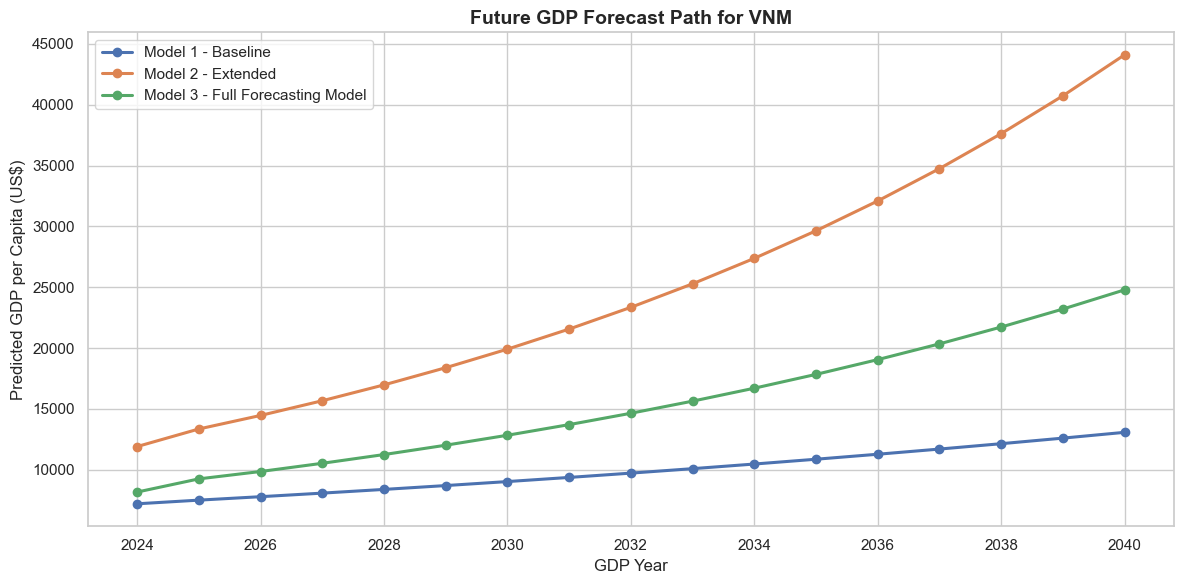

In [18]:
plt.figure(figsize=(12, 6))
plt.plot(
    gdp_forecast_path["predicted_gdp_year"],
    gdp_forecast_path["predicted_gdp_model_1"],
    marker="o",
    linewidth=2.2,
    label="Model 1 - Baseline"
)
plt.plot(
    gdp_forecast_path["predicted_gdp_year"],
    gdp_forecast_path["predicted_gdp_model_2"],
    marker="o",
    linewidth=2.2,
    label="Model 2 - Extended"
)
plt.plot(
    gdp_forecast_path["predicted_gdp_year"],
    gdp_forecast_path["predicted_gdp_model_3"],
    marker="o",
    linewidth=2.2,
    label="Model 3 - Full Forecasting Model"
)

plt.title(f"Future GDP Forecast Path for {country_code_input}", fontsize=14, fontweight="bold")
plt.xlabel("GDP Year")
plt.ylabel("Predicted GDP per Capita (US$)")
plt.legend()
plt.tight_layout()
plt.show()
